# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [ ]:
# Restart the Kernel after you execute this command.

!pip install ipywidgets==8.1.5

**Important: Restart the Kernel at this moment**

## Imports

In [2]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`!

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [3]:
# Define transforms
## YOUR CODE HERE ##
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,), (0.5,))])

# Create training set and define training dataloader
## YOUR CODE HERE ##
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

# Create test set and define test dataloader
## YOUR CODE HERE ##
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

***DOUBLE CLICK THIS CELL TO MODIFY***

The chosen preprocessing converts images to tensors and standardizes their pixel values to stabilize and speed up training.

-   ToTensor converts the raw MNIST images into PyTorch tensors with pixel values scaled to [0,1][0,1], which is the required format for feeding data into the network and performing gradient-based optimization.

-   Normalize((0.5,), (0.5,)) recenters the inputs around zero and scales them to a consistent range, helping gradients propagate more smoothly and improving convergence and overall model performance.

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [4]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)

    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))

        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
4


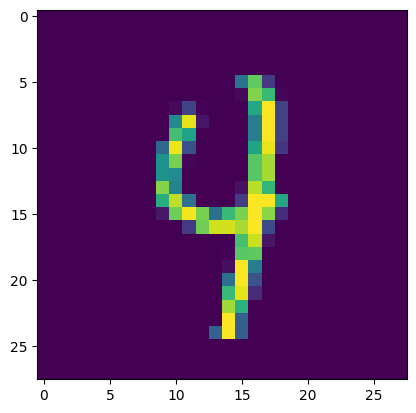

5


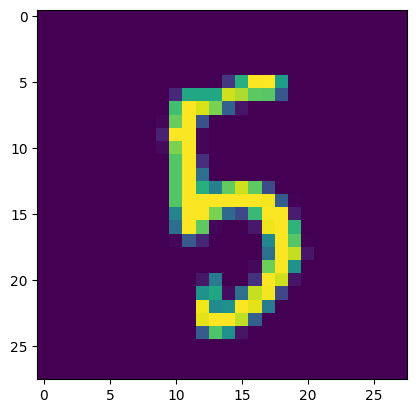

6


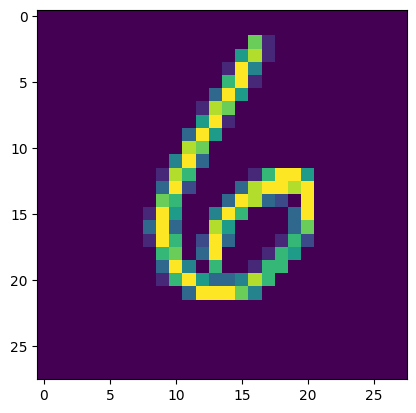

2


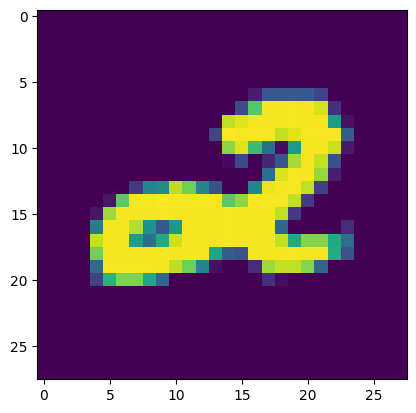

6


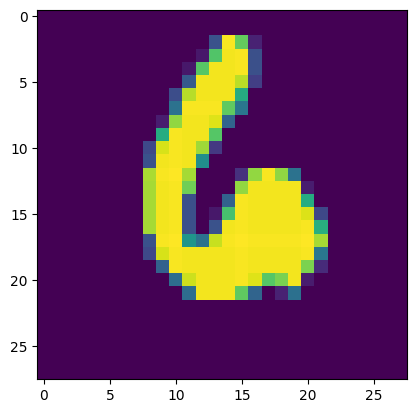

In [5]:
# Explore data
## YOUR CODE HERE ##

dataiter = iter(trainloader)
images, labels = next(dataiter)

print(f"Image batch shape: {images.shape}") # Should be [64, 1, 28, 28]
print(f"Label batch shape: {labels.shape}")

# Visualize 5 images using the provided function
show5(trainloader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like.

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [16]:
## YOUR CODE HERE ##

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Flatten the 28x28 image into a 784-element vector
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10) # 10 output classes for digits 0-9

    def forward(self, x):
        # Flatten the input
        x = x.view(-1, 28 * 28)
        # Apply activation functions (ReLU) between layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Instantiate the model
model = Net()

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [17]:
## YOUR CODE HERE ##

# optimizer = optim.Adam(model.parameters(), lr=0.0005)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch.
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [18]:
## YOUR CODE HERE ##

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move the model to the chosen device
model.to(device)

Using device: cpu


Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)

In [19]:
## YOUR CODE HERE ##
# 1. Define training parameters
epochs = 10
train_loss_history = []

print(f"Starting training on {device}...")

for epoch in range(epochs):
    running_loss = 0.0
    epoch_total_loss = 0.0

    # Set model to training mode
    model.train()

    for i, data in enumerate(trainloader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        # Move them to the GPU/CPU
        inputs, labels = data[0].to(device), data[1].to(device)

        # 2. Zero the parameter gradients
        # PyTorch accumulates gradients, so we must clear them every batch
        optimizer.zero_grad()

        # 3. Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Optimize (Update weights)
        optimizer.step()

        # Record statistics
        running_loss += loss.item()
        epoch_total_loss += loss.item()

        # Print every 250 batches
        if i % 250 == 249:
            print(f'Epoch {epoch + 1} | Batch {i + 1:5d} | Loss: {running_loss / 250:.3f}')
            running_loss = 0.0

    # Calculate and store average loss for the epoch
    avg_loss = epoch_total_loss / len(trainloader)
    train_loss_history.append(avg_loss)
    print(f'==> Epoch {epoch + 1} Complete. Average Loss: {avg_loss:.4f}\n')

print('Finished Training')

Starting training on cpu...
Epoch 1 | Batch   250 | Loss: 0.871
Epoch 1 | Batch   500 | Loss: 0.372
Epoch 1 | Batch   750 | Loss: 0.304
==> Epoch 1 Complete. Average Loss: 0.4656

Epoch 2 | Batch   250 | Loss: 0.238
Epoch 2 | Batch   500 | Loss: 0.205
Epoch 2 | Batch   750 | Loss: 0.193
==> Epoch 2 Complete. Average Loss: 0.2062

Epoch 3 | Batch   250 | Loss: 0.166
Epoch 3 | Batch   500 | Loss: 0.145
Epoch 3 | Batch   750 | Loss: 0.150
==> Epoch 3 Complete. Average Loss: 0.1515

Epoch 4 | Batch   250 | Loss: 0.132
Epoch 4 | Batch   500 | Loss: 0.134
Epoch 4 | Batch   750 | Loss: 0.129
==> Epoch 4 Complete. Average Loss: 0.1277

Epoch 5 | Batch   250 | Loss: 0.115
Epoch 5 | Batch   500 | Loss: 0.115
Epoch 5 | Batch   750 | Loss: 0.110
==> Epoch 5 Complete. Average Loss: 0.1117

Epoch 6 | Batch   250 | Loss: 0.100
Epoch 6 | Batch   500 | Loss: 0.099
Epoch 6 | Batch   750 | Loss: 0.096
==> Epoch 6 Complete. Average Loss: 0.0980

Epoch 7 | Batch   250 | Loss: 0.090
Epoch 7 | Batch   500 | 

Plot the training accuracy and validation accuracy.

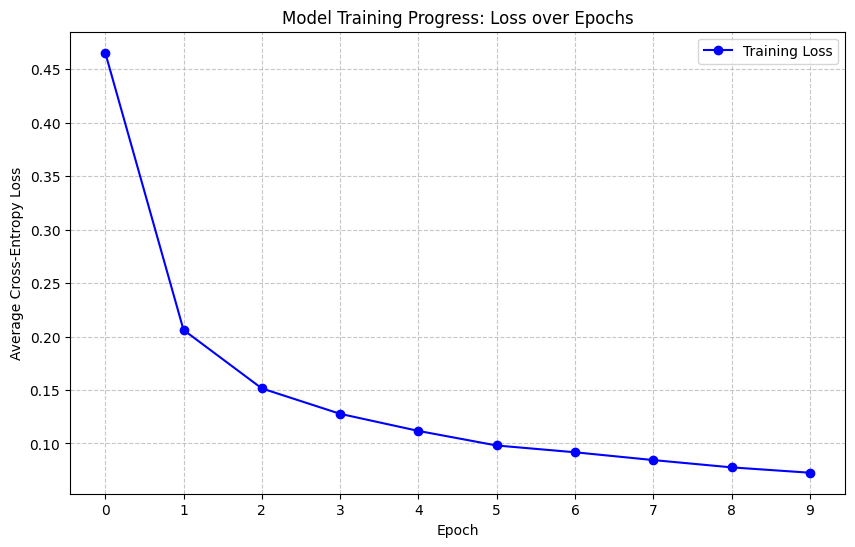

In [20]:
## YOUR CODE HERE ##


# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss', marker='o', color='b')

# Add titles and labels
plt.title('Model Training Progress: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
plt.xticks(range(len(train_loss_history))) # Ensure x-axis shows integer epoch numbers
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction.

If your accuracy is over 90%, great work, but see if you can push a bit further!
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [21]:
## YOUR CODE HERE ##
def model_accuracy(model):
  correct = 0
  total = 0

  # Set model to evaluation mode
  model.eval()

  # Disabling gradient calculation saves memory and computation
  with torch.no_grad():
      for data in testloader:
          images, labels = data[0].to(device), data[1].to(device)

          # Forward pass to get outputs
          outputs = model(images)

          # The class with the highest score is our prediction
          # torch.max returns (values, indices); we only need the indices (predictions)
          _, predicted = torch.max(outputs, 1)

          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  accuracy = 100 * correct / total
  print(f'Accuracy of the network on the 10,000 test images: {accuracy:.2f}%')

  return accuracy

# Evaluate the model1
model1_acc = model_accuracy(model)
print(f"Model 1 Accuracy: {model1_acc:.2f}%")

Accuracy of the network on the 10,000 test images: 97.69%
Model 1 Accuracy: 97.69%


## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [22]:

transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate slightly <<<<<<<
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Flatten the 28x28 image into a 784-element vector
        self.fc1 = nn.Linear(28 * 28, 128)
        self.dropout1 = nn.Dropout(p=0.2)  # Add dropout layer <<<<<<<<<
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(p=0.2)  # Add dropout layer <<<<<<<<<
        self.fc3 = nn.Linear(64, 10) # 10 output classes for digits 0-9

    def forward(self, x):
        # Flatten the input
        x = x.view(-1, 28 * 28)
        # Apply activation functions (ReLU) between layers
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Instantiate the model
model2 = Net()


optimizer = optim.SGD(model2.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

# Example: Decay LR by a factor of 0.1 every 5 epochs
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)  # scheduler had a bad effect!

epochs = 10
train_loss_history = []

print(f"Starting training on {device}...")

for epoch in range(epochs):
    running_loss = 0.0
    epoch_total_loss = 0.0

    # Set model2 to training mode
    model2.train()

    for i, data in enumerate(trainloader, 0):
        # Get the inputs; data is a list of [inputs, labels]
        # Move them to the GPU/CPU
        inputs, labels = data[0].to(device), data[1].to(device)

        # 2. Zero the parameter gradients
        # PyTorch accumulates gradients, so we must clear them every batch
        optimizer.zero_grad()

        # 3. Forward pass

        outputs = model2(inputs)
        loss = criterion(outputs, labels)

        # 4. Backward pass
        loss.backward()

        # 5. Optimize (Update weights)
        optimizer.step()
        # scheduler.step() # Call this after the optimizer

        # Record statistics
        running_loss += loss.item()
        epoch_total_loss += loss.item()

        # Print every 250 batches
        if i % 250 == 249:
            print(f'Epoch {epoch + 1} | Batch {i + 1:5d} | Loss: {running_loss / 250:.3f}')
            running_loss = 0.0

    # Calculate and store average loss for the epoch
    avg_loss = epoch_total_loss / len(trainloader)
    train_loss_history.append(avg_loss)
    print(f'==> Epoch {epoch + 1} Complete. Average Loss: {avg_loss:.4f}\n')

print('Finished Training')

Starting training on cpu...
Epoch 1 | Batch   250 | Loss: 1.002
Epoch 1 | Batch   500 | Loss: 0.464
Epoch 1 | Batch   750 | Loss: 0.390
==> Epoch 1 Complete. Average Loss: 0.5639

Epoch 2 | Batch   250 | Loss: 0.311
Epoch 2 | Batch   500 | Loss: 0.287
Epoch 2 | Batch   750 | Loss: 0.270
==> Epoch 2 Complete. Average Loss: 0.2834

Epoch 3 | Batch   250 | Loss: 0.240
Epoch 3 | Batch   500 | Loss: 0.234
Epoch 3 | Batch   750 | Loss: 0.237
==> Epoch 3 Complete. Average Loss: 0.2339

Epoch 4 | Batch   250 | Loss: 0.209
Epoch 4 | Batch   500 | Loss: 0.196
Epoch 4 | Batch   750 | Loss: 0.212
==> Epoch 4 Complete. Average Loss: 0.2030

Epoch 5 | Batch   250 | Loss: 0.188
Epoch 5 | Batch   500 | Loss: 0.174
Epoch 5 | Batch   750 | Loss: 0.188
==> Epoch 5 Complete. Average Loss: 0.1841

Epoch 6 | Batch   250 | Loss: 0.170
Epoch 6 | Batch   500 | Loss: 0.174
Epoch 6 | Batch   750 | Loss: 0.170
==> Epoch 6 Complete. Average Loss: 0.1702

Epoch 7 | Batch   250 | Loss: 0.158
Epoch 7 | Batch   500 | 

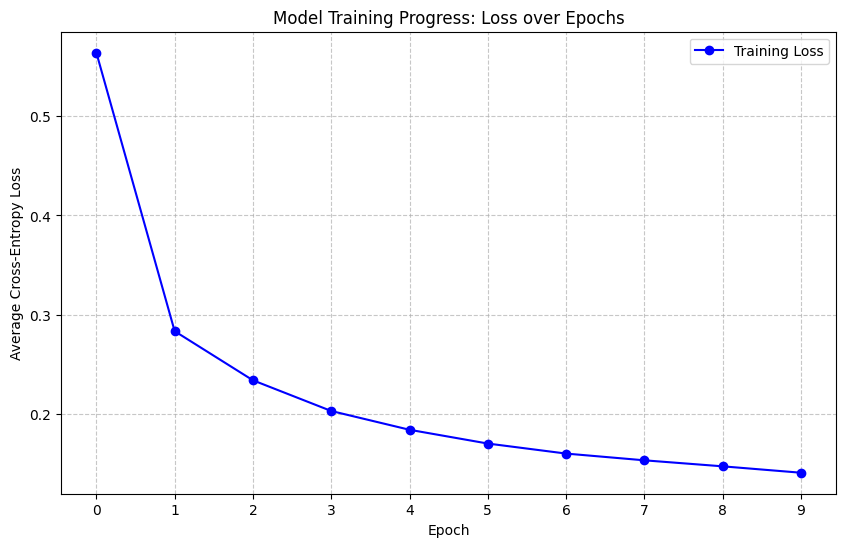

In [23]:

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss', marker='o', color='b')

# Add titles and labels
plt.title('Model Training Progress: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Average Cross-Entropy Loss')
plt.xticks(range(len(train_loss_history))) # Ensure x-axis shows integer epoch numbers
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [24]:
model2_acc = model_accuracy(model2)
print(f"Model 1 Accuracy: {model2_acc:.2f}%")

Accuracy of the network on the 10,000 test images: 97.02%
Model 1 Accuracy: 97.02%


## Saving your model
Using `torch.save`, save your model for future loading.

In [25]:
## YOUR CODE HERE ##
if model1_acc > model2_acc:
  torch.save(model.state_dict(), 'mnist_model.pth')
  print(f"Model1 with accuracy {model1_acc} saved.")
else:
  torch.save(model2.state_dict(), 'mnist_model.pth')
  print(f"Model2 with accuracy {model2_acc} saved.")


print(f"The Best Model saved.")

Model1 with accuracy 97.69 saved.
The Best Model saved.


* The hyper-tunning changes didn't provide a better result, so we saved the 1st model with accuracy 97.69%